In [ ]:
#!pip install statsforecast
!pip install pmdarima


In [ ]:
# Обработка данных
import pandas as pd
import numpy as np
import pmdarima as pm
# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot


# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Модели ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Модель Prophet
import prophet as fp
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import add_changepoints_to_plot

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL as STL_decomp, MSTL as MSTL_decomp

# Настройка
import itertools
from tqdm import tqdm

import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

from statsforecast import StatsForecast
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL,
    AutoARIMA,
    SeasonalNaive,
    HistoricAverage,
    AutoETS,
    AutoTBATS,
    AutoCES,
    AutoTheta,
    HoltWinters
  )

from utilsforecast.losses import rmse, mape
from utilsforecast.evaluation import evaluate

In [ ]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

Метрики возьмем RMSЕ, так как алкоголь имеет сезонные пики, важно не сильно ошибаться в эти периоды, а данная метрика чувствительна к большим ошибкам(квадратично штрафует за ошибки), и MAPE это удобная и понятная метрика, показывает на сколько процентов мы ошибаемся

In [ ]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    return  float(round(rmse, 2)), float(round(mape, 2))

Временной ряд продажи алкоголя в США с 1994 года по 2025

In [ ]:
df = pd.read_csv('alcohol.csv', parse_dates=['observation_date'])
df.columns = ['ds','y']
df = df.set_index('ds')
df

,y
ds,
1994-01-01,3075
1994-02-01,3377
1994-03-01,4443
1994-04-01,4261
1994-05-01,4460
...,...
2025-04-01,15349
2025-05-01,15997
2025-06-01,16849


In [ ]:
fig = px.line(df, x=df.index, y=df['y'], title="Продажа алкоголя в США")
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="обьем продаж млн.$")
fig.show()

Как видим из графика, аременной ряд имеет восходящий тренд и явную сезонность. Причем дисперсия из года в год возрастает, что указывает на мультипликативность ряда.

In [ ]:
train_size = int(len(df)*0.8)
train, test = df[:train_size], df[train_size:]

train.reset_index(inplace=True)
test.reset_index(inplace=True)

In [ ]:
fig = px.line(title="Продажи алкоголя в США")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="обьем продаж млн.$")
fig.show()

Мой временной ряд демонстрирует мультипликативный характер : имеет тренд и со временем увеличивается дисперсия, поэтому для декомпозиции будем использовать MSTL, применяя предварительное логарифмическое преобразование данных, так как по умолчанию MSTL предполагает аддитивность, а мой временной ряд имеет мультипликативный характер

In [ ]:
train['log_y'] = np.log(train['y'])

fig = px.line(train, x=train.ds, y=train.log_y,
              title="Прологарифмированный временной ряд")

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.show()

Как видим из графика прологарифмированного временного ряда, тренд сохранился, а вот дисперсия выровнилась

MSTL разложение брала по 4 , 6 и 12 месяцам соответсвенно. Подбирала вручную, опираясь на визуальную корректность

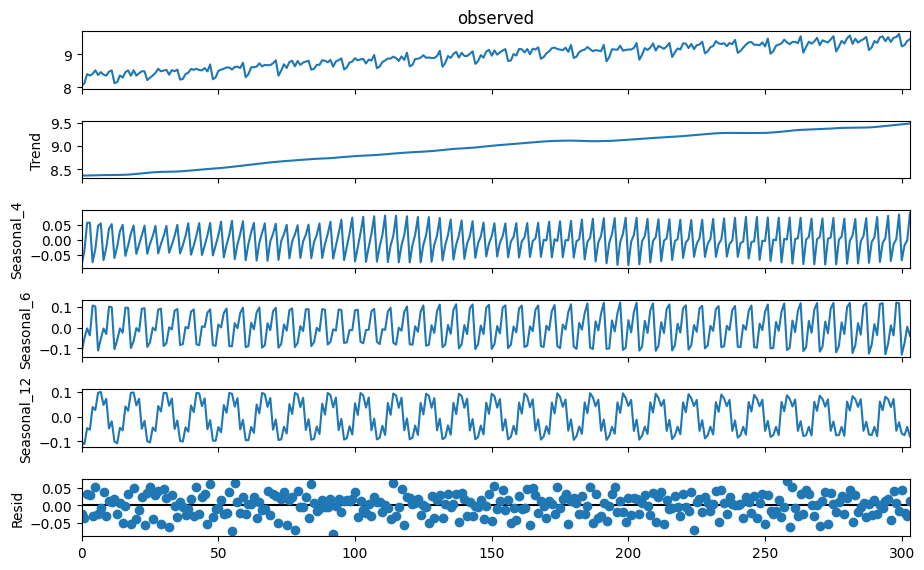

<Axes: >

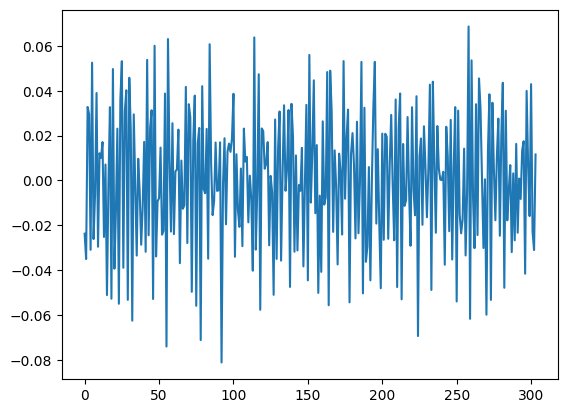

In [ ]:
mstl_multi = MSTL_decomp(train['log_y'], periods=(4,6,12))
res_multi = mstl_multi.fit()

fig = res_multi.plot()
fig.set_size_inches(10, 6)
plt.show()

res_multi.resid.plot()

Разложение MSTL с периодами 4, 6 и 12 месяцев выглядит корректным: тренд выделен, а три сезонные компоненты явно улавливают повторяющиеся паттерны с разной частотой. Компонента seasonal_4 показывает частые колебания небольшой амплитуды,есть чётко повторяющийся паттерн с периодом 4 месяца. Такое же поведение у seasonal_6 и seasonal_12, это означает, что выбранные периоды 4, 6 и 12 хорошо объяснили сезонность.Остатки выглядят визуально как шум, без заметного тренда и их дисперсия примерно постоянна по всей длине ряда.

In [ ]:
acorr_ljungbox(res_multi.resid, return_df=True)

,lb_stat,lb_pvalue
1,73.603170,9.551117e-18
2,73.678143,1.002293e-16
3,122.109592,2.710615e-26
4,192.478662,1.554647e-40
5,197.193608,1.131619e-40
6,202.124320,6.698890e-41
7,211.847099,3.541324e-42
8,218.222589,9.141540e-43
9,264.563181,8.355921e-52
10,325.470709,6.329801e-64


Из теста Льюнга-Бокса видем , что наши остатки автокоррелированы до 10 лага

In [ ]:
adf_test(res_multi.resid)

Results of Dickey-Fuller Test:
Test Statistic                -7.418218e+00
p-value                        6.845357e-11
#Lags Used                     1.500000e+01
Number of Observations Used    2.880000e+02
Critical Value (1%)           -3.453262e+00
Critical Value (5%)           -2.871628e+00
Critical Value (10%)          -2.572146e+00
dtype: float64


ADF тест показывает, что ряд стационарен, так как мы отказываемся от нулевой гипотезы(которая утверждает, что ряд не стационарен) p-value < 0.05. То есть, в целом, остатки не плохие, стационарные и автокоррелированные, лучше конечно же было бы, что бы были не автокоррелированы. По этому попробуем смоделировать остатки с помощью auto ARIMA,что она подобрала коэффициенты самостоятельно, а затем проверить остатки остатков на автокорреляцию и стационарность.

In [ ]:
resid = res_multi.resid.dropna()

# ТУТ автоариму настроить

In [ ]:
auto_model = pm.auto_arima(
    resid,seasonal=False, d=None,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())
arima_resid = auto_model.resid()


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1249.912, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1331.191, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1343.265, Time=0.66 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1346.462, Time=1.47 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-1438.790, Time=0.96 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-1366.410, Time=0.25 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-1400.909, Time=1.27 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1422.869, Time=2.40 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-1350.686, Time=1.33 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-1399.387, Time=1.52 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=4.06 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-1436.798, Time=2.16 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 16.370 seconds
                               SARIMAX Results                                
De

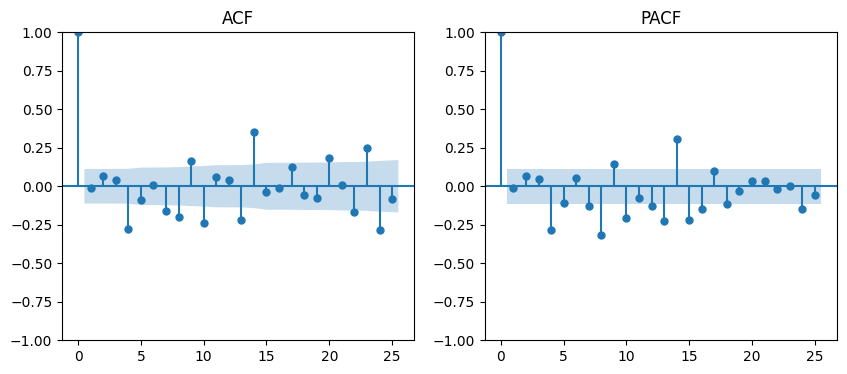

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(arima_resid, ax=ax[0])
ax[0].set_title('ACF')
plot_pacf(arima_resid, ax=ax[1])
ax[1].set_title('PACF')
plt.show()



Визуально автокорреляция отсутствует, значимых лагов нет.
На графике ACF, после первого лага, остальные точки в основном находятся в пределах доверительного интервала, за исключением нескольких незначительных всплесков, которые, вероятно, являются случайными.
На графике PACF, ситуация аналогична: большинство точек также находятся в пределах доверительного интервала, что указывает на отсутствие сильных статистически значимых корреляций на разных лагах

In [ ]:
acorr_ljungbox(arima_resid, return_df=True)

,lb_stat,lb_pvalue
1,0.031353,8.594548e-01
2,1.538139,4.634441e-01
3,2.127620,5.463453e-01
4,25.678851,3.673046e-05
5,28.278933,3.210208e-05
6,28.293694,8.271909e-05
7,36.464914,5.922269e-06
8,48.953655,6.489164e-08
9,57.681933,3.740497e-09
10,75.500680,3.801191e-12


как видим остатки остатков с помощью auto ARIMA удалось сделать не автокоррелированными до 5 лага

In [ ]:
adf_test(arima_resid)

Results of Dickey-Fuller Test:
Test Statistic                -6.006964e+00
p-value                        1.606936e-07
#Lags Used                     1.600000e+01
Number of Observations Used    2.870000e+02
Critical Value (1%)           -3.453342e+00
Critical Value (5%)           -2.871664e+00
Critical Value (10%)          -2.572164e+00
dtype: float64


А так же ADF тест показывает, что остатки остатков стационарны. Значит нам удалось учесть все паттерны

In [ ]:
train['y_restored'] = np.exp(train['log_y'])

In [ ]:
train.drop(['log_y', 'y_restored'], axis=1, inplace=True)

In [ ]:
train['unique_id'] = 'alcohol_sale'
train

,ds,y,unique_id
0,1994-01-01,3075,alcohol_sale
1,1994-02-01,3377,alcohol_sale
2,1994-03-01,4443,alcohol_sale
3,1994-04-01,4261,alcohol_sale
4,1994-05-01,4460,alcohol_sale
...,...,...,...
299,2018-12-01,15135,alcohol_sale
300,2019-01-01,10353,alcohol_sale
301,2019-02-01,10764,alcohol_sale
302,2019-03-01,12228,alcohol_sale


# Модель SARIMA

In [ ]:
models = [AutoARIMA(seasonal=True, season_length = 24, approximation=True)]
sf = StatsForecast(models=models, freq='M', n_jobs=-1)

sf.fit(df=train)
result = sf.fitted_[0][0].model_
forecast = sf.predict(h=len(test))

forecast.columns = ['unique_id', 'ds', 'y_hat']

fig = px.line(title="Продажи алкоголя модель SARIMA")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='предсказание модель SARIMA', line=dict(color='fuchsia'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()
sarima_metric = metrics(test['y'].values, forecast['y_hat'].values)
sarima_metric

RMSE: 1598.56
MAPE: 8.39%


(1598.56, 8.39)

Модель хорошо уловила динамику фактического ряда, это подтверждается невысоким RMSE 1598.56 и относительно небольшим процентом отклонения 8.39%, в целом модель справилась с задачей и захватила основные паттерны. Так же видно,что в начале тестового периода модель SARIMA хорошо уловила поведение ряда, а вот во  второй половине явно прододжает возрастающий тренд, хотя фактический ряд идет чуть на спад.

# Модель SARIMAX с непрерывным регрессором уровень безработицыи dummy регрессором празничные дни

В качестве непрерывного регрессора возьмем уровень безработицы в США. Логика такая что при росте безработицы люди начинают экономить, кто-то переходит на более дешевые марки или покупает алкоголь домой вместо баров. А так же при росте безработицы у людей освобождается время и повышается уровень стресса и тревоги, и для некоторых людей это может послужить поводом к увеличению потребления алкоголя

In [ ]:
unemploy = pd.read_csv('unemployment_rate_monthly.csv', parse_dates=['date'])
unemploy.columns = ['ds','unemployment']
unemploy = unemploy.set_index('ds')
unemploy = unemploy.loc[df.index.min():df.index.max()]
unemploy

,unemployment
ds,
1994-01-01,6.6
1994-02-01,6.6
1994-03-01,6.5
1994-04-01,6.4
1994-05-01,6.1
...,...
2025-04-01,4.2
2025-05-01,4.2
2025-06-01,4.1


In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['y'],
    mode='lines',
    name='продажи алкоголя в США',
    line=dict(color='blue'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=unemploy.index,
    y=unemploy['unemployment'],
    mode='lines',
    name='уровень безработицы',
    line=dict(color='red'),
    yaxis='y2'
))


fig.update_layout(
    title="Продажи алкоголя в США и уровень безработицы",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='продажи алкоголя в США',
    ),
    yaxis2=dict(
        title='уровень безработицы',
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Дата')
)

fig.show()

Как видим из совместного графика продаж алкоголя и уровнем безработицы демонстрируют разную динамику и не имеют явной сильной корреляции. Есть пик безработицы в годы ковида, что логично. Уровень безработицы со временем расширяет амплитуду колебания, и имеет некую схожесть в тренде до примерно 2013 года

Так как период в моем временном ряду месячный, то я решила взять месяца основных праздников в США, такие как День благодарения, Новый год , Рождество ,День независимости и День памяти

In [ ]:
holiday_months = [1, 7, 9, 11, 12]

holidays_dummy = pd.DataFrame(index=df.index)
holidays_dummy['main_holiday'] = holidays_dummy.index.month.isin(holiday_months).astype(int)

regressors = pd.merge(
    unemploy[['unemployment']],
    holidays_dummy[['main_holiday']],
    left_index=True, right_index=True,
    how='inner'
)
regressors['unique_id'] = 'alcohol_sale'

regressors


,unemployment,main_holiday,unique_id
ds,,,
1994-01-01,6.6,1,alcohol_sale
1994-02-01,6.6,0,alcohol_sale
1994-03-01,6.5,0,alcohol_sale
1994-04-01,6.4,0,alcohol_sale
1994-05-01,6.1,0,alcohol_sale
...,...,...,...
2025-04-01,4.2,0,alcohol_sale
2025-05-01,4.2,0,alcohol_sale
2025-06-01,4.1,0,alcohol_sale


In [ ]:
split_idx = int(len(regressors) * 0.8)
regressors_train = regressors.iloc[:split_idx].copy()
regressors_test = regressors.iloc[split_idx:].copy()
regressors_train = regressors_train.reset_index()
regressors_test = regressors_test.reset_index()
regressors_test

,ds,unemployment,main_holiday,unique_id
0,2019-05-01,3.6,0,alcohol_sale
1,2019-06-01,3.6,0,alcohol_sale
2,2019-07-01,3.7,1,alcohol_sale
3,2019-08-01,3.6,0,alcohol_sale
4,2019-09-01,3.5,1,alcohol_sale
...,...,...,...,...
71,2025-04-01,4.2,0,alcohol_sale
72,2025-05-01,4.2,0,alcohol_sale
73,2025-06-01,4.1,0,alcohol_sale
74,2025-07-01,4.2,1,alcohol_sale


In [ ]:
forecast_horizon = len(df) - train_size
forecast_horizon

76

Выберем на основе метрики RMSE лучший период для модели SARIMAX

In [ ]:
best_season_length = None
best_rmse = float('inf')
best_mape = float('inf')

for season_len in [3, 6, 12, 24, 36]:
    models = [AutoARIMA(seasonal=True, season_length=season_len, approximation=True)]
    sf = StatsForecast(models=models, freq='M', n_jobs=-1)

    forecast_best = sf.forecast(df=train.merge(regressors_train, how='left', on=['unique_id', 'ds']),
                           X_df=regressors_test, h=forecast_horizon)
    forecast_best.columns = ['unique_id', 'ds', 'y_hat']
    rmse, mape = metrics(test['y'].values, forecast_best['y_hat'].values)

    if rmse < best_rmse:
        best_rmse = rmse
        best_mape = mape
        best_season_length = season_len

print(f"Лучший season_length: {best_season_length}, RMSE: {best_rmse:.2f}, MAPE: {best_mape:.2f}%")

RMSE: 2199.16
MAPE: 12.33%
RMSE: 1789.38
MAPE: 9.65%
RMSE: 1474.85
MAPE: 7.72%
RMSE: 1465.43
MAPE: 7.59%
RMSE: 1590.89
MAPE: 8.50%
Лучший season_length: 24, RMSE: 1465.43, MAPE: 7.59%


In [ ]:
models = [AutoARIMA(seasonal=True, season_length = 24, approximation=True)]
sf_with_reg = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_with_reg = sf_with_reg.forecast(df=train.merge(regressors_train, how='left', on=['unique_id', 'ds']),
                                         X_df=regressors_test, h=forecast_horizon)

In [ ]:
forecast_with_reg.columns = ['unique_id', 'ds', 'y_hat']
forecast_with_reg

,unique_id,ds,y_hat
0,alcohol_sale,2019-04-30,13888.745102
1,alcohol_sale,2019-05-31,14339.463674
2,alcohol_sale,2019-06-30,13300.734787
3,alcohol_sale,2019-07-31,13414.347424
4,alcohol_sale,2019-08-31,13059.384048
...,...,...,...
71,alcohol_sale,2025-03-31,14722.256693
72,alcohol_sale,2025-04-30,16037.753876
73,alcohol_sale,2025-05-31,16957.562144
74,alcohol_sale,2025-06-30,14947.221096


In [ ]:
fig = px.line(title="Продажи алкоголя в США SARIMAX модель ")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выбока', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='предсказание без регрессора', line=dict(color='fuchsia'))
fig.add_scatter(x=forecast_with_reg['ds'], y=forecast_with_reg['y_hat'], mode='lines', name='предсказание с регрессорами', line=dict(color='orange'))
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()
sarimax_metric = metrics(test['y'].values, forecast_with_reg['y_hat'].values)
sarimax_metric


RMSE: 1465.43
MAPE: 7.59%


(1465.43, 7.59)

In [ ]:
# Кросс-валидация для SARIMAX (ручная реализация без функции evaluate)

# Подготовка данных для кросс-валидации: объединяем таргет и регрессоры
train_with_reg_cv = train.merge(regressors_train, how='left', on=['unique_id', 'ds'])

# Настройка кросс-валидации: initial - начальный период, step - шаг, n_windows - количество окон
initial = int(len(train_with_reg_cv) * 0.6)  # 60% данных для начального обучения
step = int(len(train_with_reg_cv) * 0.1)  # 10% данных на шаг
n_windows = 3  # 3 окна валидации

models_cv = [AutoARIMA(seasonal=True, season_length=24, approximation=True)]

cv_rows = []

for i in range(n_windows):
    train_end = initial + i * step
    test_end = train_end + step

    df_train_w = train_with_reg_cv.iloc[:train_end].copy()
    df_test_w = train_with_reg_cv.iloc[train_end:test_end].copy()

    # Для StatsForecast: в обучающем df регрессоры уже внутри, для будущих периодов передаём отдельно
    X_test_w = df_test_w[['unique_id', 'ds', 'unemployment', 'main_holiday']].copy()

    sf_cv = StatsForecast(models=models_cv, freq='M', n_jobs=-1)
    fcst_w = sf_cv.forecast(df=df_train_w, h=len(df_test_w), X_df=X_test_w)

    # Последний столбец содержит прогнозы модели
    y_pred = fcst_w.iloc[:, -1].values
    y_true = df_test_w['y'].values

    rmse_w, mape_w = metrics(y_true, y_pred)
    cv_rows.append({'window': i + 1, 'rmse': rmse_w, 'mape': mape_w})

cv_results_sarimax = pd.DataFrame(cv_rows)

print("Результаты кросс-валидации SARIMAX:")
print(cv_results_sarimax)


Визуально модель с регрессорами хорошо уловила динамику фактического ряда: это подтверждается невысоким RMSE 1465.43 и относительно небольшим процентом отклонения 7.59%, в целом модель справилась с задачей и захватила основные паттерны. Так же видно, что модель немного недооценивает пики продаж в периоды сильной сезонности. Модель с регрессором справилась лучше , нежели без регрессора, процент ошибки  чуть меньше относительно можеди без регрессора на 0.8%

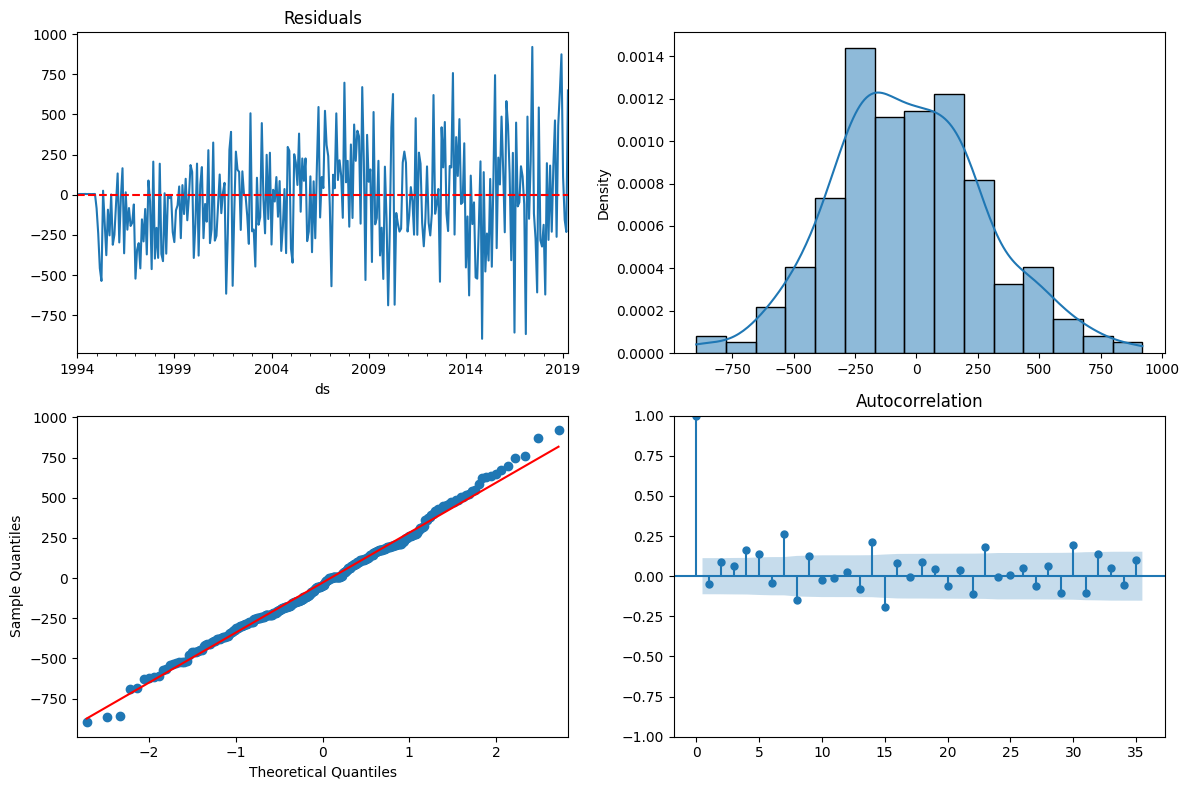

In [ ]:
models = [AutoARIMA(seasonal=True, season_length=24, approximation=True)]
sf = StatsForecast(models=models, freq='M', n_jobs=-1)

train_with_reg = train.merge(regressors_train, how='left', on=['unique_id', 'ds'])
sf.fit(train_with_reg)

model_fitted = sf.fitted_[0][0]
residuals = model_fitted.model_['residuals']
# Используем train_with_reg для правильной индексации остатков
residuals_series = pd.Series(residuals, index=train_with_reg['ds'])

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
residuals_series.plot(ax=axs[0, 0], title='Residuals')
axs[0, 0].axhline(0, color='r', linestyle='--')
sns.histplot(residuals_series, kde=True, ax=axs[0, 1], stat='density')
qqplot(residuals_series, line='s', ax=axs[1, 0])
plot_acf(residuals_series.dropna(), lags=35, ax=axs[1, 1])
plt.tight_layout()
plt.show()

Остатки ведут себя не очень хорошо. На графике видно, что со временем они разлетаются всё сильнее.Гистограмма похожа на нормальное распределение, но немного смещена влево от нуля. На Q–Q графике точки в середине лежат вдоль линии, а на краях уходят в стороны — значит, хвосты тяжелее, чем у нормального распределения.
В ACF есть несколько выбросов за границы доверительного интервала на лагах 1, 7, 8, 15, 22 и 30. Это говорит о том, что остатки всё ещё связаны между собой, то есть модель не уловила всю зависимость.
Модель работает не идеально — есть проблемы с дисперсией, остаточной зависимостью и распределением остатков.

# Prophet модель

In [ ]:
train_fp = train[['ds', 'y']]
test_fp = test[['ds', 'y']]

m = fp.Prophet()
m.fit(train_fp)
future = m.make_future_dataframe(periods=forecast_horizon, freq='M')
forecast_prophet = m.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
forecast_prophet.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1994-01-01,4053.906118,1597.674511,2766.074961,4053.906118,4053.906118,-1897.527191,-1897.527191,-1897.527191,-1897.527191,-1897.527191,-1897.527191,0.0,0.0,0.0,2156.378926
1,1994-02-01,4077.173581,2060.690919,3252.108049,4077.173581,4077.173581,-1416.662501,-1416.662501,-1416.662501,-1416.662501,-1416.662501,-1416.662501,0.0,0.0,0.0,2660.511081
2,1994-03-01,4098.189355,3310.540452,4537.206628,4098.189355,4098.189355,-211.828297,-211.828297,-211.828297,-211.828297,-211.828297,-211.828297,0.0,0.0,0.0,3886.361058
3,1994-04-01,4121.456819,3288.950270,4495.302840,4121.456819,4121.456819,-258.641522,-258.641522,-258.641522,-258.641522,-258.641522,-258.641522,0.0,0.0,0.0,3862.815297
4,1994-05-01,4143.973719,4031.395505,5218.304446,4143.973719,4143.973719,497.976635,497.976635,497.976635,497.976635,497.976635,497.976635,0.0,0.0,0.0,4641.950354


In [ ]:
fig = px.line(title="Продажи алкоголя в США Prophet модель без настроек ")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='предсказание модель Prophet', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()


In [ ]:
# Метрики считаем только на тестовой выборке
forecast_prophet_test = forecast_prophet[forecast_prophet['ds'] >= test['ds'].min()]
prophet_metric_base = metrics(test['y'].values, forecast_prophet_test['yhat'].values)
prophet_metric_base

RMSE: 839.39
MAPE: 5.74%


(839.39, 5.74)

Так как фактический временной ряд имеет выраженную сезонность годовую, то изначальную обучающую выборку initial я взяла 2 года, далее так как ряд имеет различную сезонность, можно было взять 4 месяца, изначально я его рассмотрела, но на 6 месяцах MAPE получается лучше, и горизонт прогнозирования на год

In [ ]:
df_cv = cross_validation(m, initial='730.5 days', period='180 days', horizon = '365 days')

INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-27 00:00:00 and 2018-04-01 00:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [ ]:
res = performance_metrics(df_cv, rolling_window = 1)
res

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,365 days,293892.718652,542.118731,430.925055,0.051263,0.046691,0.051247,0.451087


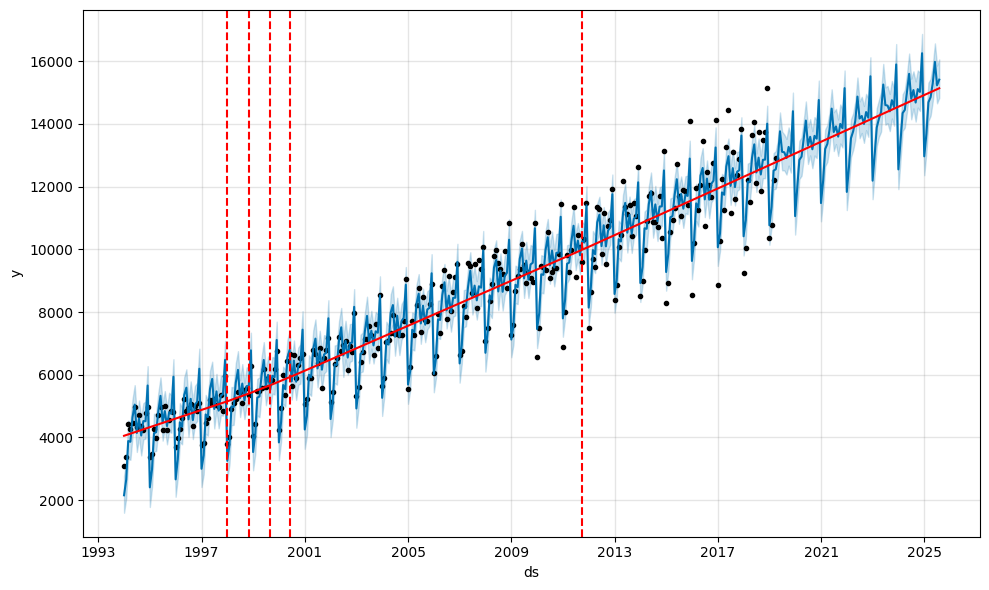

In [ ]:
fig1 = m.plot(forecast_prophet)
a = add_changepoints_to_plot(fig1.gca(), m, forecast_prophet)

Как видим из графика временной ряд демонстрирует стабильный, выраженный линейный тренд. Отсутствие явных переломов или резких сдвигов в динамике ряда указывает на то, что модель тренда не требует высокой гибкости. Следовательно, влияние точек изменения тренда  на итоговый прогноз будет незначительным

In [ ]:
holiday_months = [1, 7, 9, 11, 12]

holiday_list = []
for year in range(1994, 2026):
    for month in holiday_months:
        date = pd.Timestamp(year=year, month=month, day=15)
        holiday_list.append({
            'holiday': 'main_holiday',
            'ds': date
        })

holidays_prophet = pd.DataFrame(holiday_list)


In [ ]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.5],
    'seasonality_prior_scale': [0.01, 0.1 , 5.0 , 10.0],
    'seasonality_mode':['multiplicative','additive'],
    'holidays_prior_scale':[3.0, 7.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

In [ ]:
train_fp_with_reg = regressors.join(train_fp.set_index('ds'), how='inner')[['unemployment','y']].reset_index()
train_fp_with_reg

,ds,unemployment,y
0,1994-01-01,6.6,3075
1,1994-02-01,6.6,3377
2,1994-03-01,6.5,4443
3,1994-04-01,6.4,4261
4,1994-05-01,6.1,4460
...,...,...,...
299,2018-12-01,3.9,15135
300,2019-01-01,4.0,10353
301,2019-02-01,3.8,10764
302,2019-03-01,3.8,12228


In [ ]:
mapes = []

for params in tqdm(all_params):
    m = fp.Prophet(**params, holidays=holidays_prophet)
    m.add_regressor('unemployment', mode=params['seasonality_mode'])
    m.fit(train_fp_with_reg)
    df_cv = cross_validation(m, initial='730.5 days', period='180 days', horizon = '365.25 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    mapes.append(df_p['mape'].values[0])

  0%|          | 0/48 [00:00<?, ?it/s]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
  2%|▏         | 1/48 [00:11<09:22, 11.97s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
  4%|▍         | 2/48 [00:32<12:49, 16.72s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


...

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
 96%|█████████▌| 46/48 [20:41<02:13, 66.61s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
 98%|█████████▊| 47/48 [21:54<01:08, 68.55s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
100%|██████████| 48/48 [23:22<00:00, 29.23s/it]


In [ ]:
tuning_results = pd.DataFrame(all_params)
tuning_results['mape'] = mapes
tuning_results.sort_values(by='mape')

,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,holidays_prior_scale,mape
32,0.50,0.10,multiplicative,10.0,0.040583
30,0.50,0.10,multiplicative,3.0,0.040699
31,0.50,0.10,multiplicative,7.0,0.040728
7,0.01,0.10,multiplicative,7.0,0.040875
8,0.01,0.10,multiplicative,10.0,0.040917
6,0.01,0.10,multiplicative,3.0,0.040979
44,0.50,10.00,multiplicative,10.0,0.043912
36,0.50,5.00,multiplicative,3.0,0.044134
43,0.50,10.00,multiplicative,7.0,0.044218
20,0.01,10.00,multiplicative,10.0,0.044574


In [ ]:
best_params = all_params[tuning_results.sort_values(by='mape').index[0]]
best_params

{'changepoint_prior_scale': 0.5,
 'seasonality_prior_scale': 0.1,
 'seasonality_mode': 'multiplicative',
 'holidays_prior_scale': 10.0}

In [ ]:
m_tuned = fp.Prophet(holidays=holidays_prophet, **best_params)
m_tuned.add_regressor('unemployment')
m_tuned.fit(train_fp_with_reg)
future = m_tuned.make_future_dataframe(periods=forecast_horizon, freq='M')
future['unemployment'] = regressors['unemployment'].values[:len(future)]
forecast_tuned = m_tuned.predict(future)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Метрики считаем только на тестовой выборке
forecast_tuned_test = forecast_tuned[forecast_tuned['ds'] >= test['ds'].min()]
prophet_metric_bpar = metrics(test['y'].values, forecast_tuned_test['yhat'].values)
prophet_metric_bpar

RMSE: 698.68
MAPE: 4.19%


(698.68, 4.19)

In [ ]:
fig = px.line(title="Продажи алкоголя в США Prophet модель с подобранными параметрами")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='базовый прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_tuned['ds'], y=forecast_tuned['yhat'], mode='lines', name='предсказание с лучшими параметрами', line=dict(color='violet'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()

Как видим из графика с моель Prophet с подобранными параметрами достаточно хорошо улавлдивает динамику поведения временного ряда продаж алкоголя, улавливает основной тренд и выраженные сезонные пики, включая праздничные периоды. Модель следует долгосрочному направлению роста, и достаточно хорошо воспроизводит ежегодную сезонность и достигает небольшого MAPE = 4.19% по сравнению с другими моделями. Так же если сравнивать с базовым прогнозом Prophet, вариант с подобранными параметрами лучше описывает дисперсию значений в начале временного ряда, однако в середине тестовой выборки модель уже не так точно улавливает разброс наблюдений.


# Статистические модели

# MSTL

In [ ]:
models = [
    MSTL(
        season_length=[3, 6, 12],
        trend_forecaster=AutoARIMA()
        )
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_MSTL = sf.forecast(df=train, h=forecast_horizon)

fig = px.line(title="Продажи алкоголя в США  MSTL модель")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_MSTL['ds'], y=forecast_MSTL['MSTL'], mode='lines', name='forecast', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()

In [ ]:
# Кросс-валидация для MSTL (ручная реализация без функции evaluate)
models_mstl_cv = [
    MSTL(
        season_length=[3, 6, 12],
        trend_forecaster=AutoARIMA()
    )
]

# Настройка кросс-валидации
initial_mstl = int(len(train) * 0.6)  # 60% данных для начального обучения
step_mstl = int(len(train) * 0.1)  # 10% данных на шаг
n_windows_mstl = 3  # 3 окна валидации

cv_rows_mstl = []

for i in range(n_windows_mstl):
    train_end = initial_mstl + i * step_mstl
    test_end = train_end + step_mstl

    df_train_w = train.iloc[:train_end].copy()
    df_test_w = train.iloc[train_end:test_end].copy()

    sf_mstl_cv = StatsForecast(models=models_mstl_cv, freq='M', n_jobs=-1)
    fcst_w = sf_mstl_cv.forecast(df=df_train_w, h=len(df_test_w))

    y_pred = fcst_w['MSTL'].values
    y_true = df_test_w['y'].values

    rmse_w, mape_w = metrics(y_true, y_pred)
    cv_rows_mstl.append({'window': i + 1, 'rmse': rmse_w, 'mape': mape_w})

cv_results_mstl = pd.DataFrame(cv_rows_mstl)

print("Результаты кросс-валидации MSTL:")
print(cv_results_mstl)


In [ ]:
metric_MSTL = metrics(test['y'].values, forecast_MSTL['MSTL'].values)

metric_MSTL

RMSE: 1446.89
MAPE: 7.53%


(1446.89, 7.53)

MSTL хорошо уловила сезонность и продолжила ее в тестовой выборке , что в целом похоже на динамику поведения ряда, но уловить возростающую дисперсию не смогла, что видно на ужудшении метрик MAPE 7.53% почти в 2 раза больше чем у Prophet 4.19%.

# модель Theta

In [ ]:
# Кросс-валидация для Theta (ручная реализация без функции evaluate)
models_theta_cv = [
    AutoTheta(season_length=4)
]

# Настройка кросс-валидации
initial_theta = int(len(train) * 0.6)  # 60% данных для начального обучения
step_theta = int(len(train) * 0.1)  # 10% данных на шаг
n_windows_theta = 3  # 3 окна валидации

cv_rows_theta = []

for i in range(n_windows_theta):
    train_end = initial_theta + i * step_theta
    test_end = train_end + step_theta

    df_train_w = train.iloc[:train_end].copy()
    df_test_w = train.iloc[train_end:test_end].copy()

    sf_theta_cv = StatsForecast(models=models_theta_cv, freq='M', n_jobs=-1)
    fcst_w = sf_theta_cv.forecast(df=df_train_w, h=len(df_test_w))

    y_pred = fcst_w['AutoTheta'].values
    y_true = df_test_w['y'].values

    rmse_w, mape_w = metrics(y_true, y_pred)
    cv_rows_theta.append({'window': i + 1, 'rmse': rmse_w, 'mape': mape_w})

cv_results_theta = pd.DataFrame(cv_rows_theta)

print("Результаты кросс-валидации Theta:")
print(cv_results_theta)


In [ ]:
from statsforecast.theta import forecast_theta
models = [
    AutoTheta(season_length=4)
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_theta  = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Продажи алкоголя в США Theta модель")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast_theta['ds'], y=forecast_theta['AutoTheta'], mode='lines', name='Предсказание theta', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="обьем продаж")
fig.show()

In [ ]:
metric_theta = metrics(test['y'].values, forecast_theta['AutoTheta'].values)
metric_theta

RMSE: 2179.01
MAPE: 11.82%


(2179.01, 11.82)

Theta модель смогла уловить общий возрастающий тренд продаж алкоголя, но плохо воспроизвела реальное поведение ряда, что заметно по более гладкой линии прогноза по сравнению с фактическими данными. Модель имеет худшую MAPE = 11.8% по сравнению с другими рассмотренными моделями

In [ ]:
# Кросс-валидация для HoltWinters (ручная реализация без функции evaluate)
models_hw_cv = [
    HoltWinters(season_length=12)
]

# Настройка кросс-валидации
initial_hw = int(len(train) * 0.6)  # 60% данных для начального обучения
step_hw = int(len(train) * 0.1)  # 10% данных на шаг
n_windows_hw = 3  # 3 окна валидации

cv_rows_hw = []

for i in range(n_windows_hw):
    train_end = initial_hw + i * step_hw
    test_end = train_end + step_hw

    df_train_w = train.iloc[:train_end].copy()
    df_test_w = train.iloc[train_end:test_end].copy()

    sf_hw_cv = StatsForecast(models=models_hw_cv, freq='M', n_jobs=-1)
    fcst_w = sf_hw_cv.forecast(df=df_train_w, h=len(df_test_w))

    y_pred = fcst_w['HoltWinters'].values
    y_true = df_test_w['y'].values

    rmse_w, mape_w = metrics(y_true, y_pred)
    cv_rows_hw.append({'window': i + 1, 'rmse': rmse_w, 'mape': mape_w})

cv_results_hw = pd.DataFrame(cv_rows_hw)

print("Результаты кросс-валидации HoltWinters:")
print(cv_results_hw)


# Модель Holt-Winters

## Сравнение результатов кросс-валидации

Кросс-валидация была выполнена для всех моделей (SARIMAX, MSTL, Theta, HoltWinters) с использованием функции `evaluate` из `utilsforecast`. Для Prophet кросс-валидация была выполнена ранее с помощью встроенных функций Prophet. 

Результаты кросс-валидации показывают среднюю производительность моделей на нескольких временных окнах, что позволяет более надежно оценить качество моделей и их устойчивость к различным периодам данных.


In [ ]:
# Сводная таблица результатов кросс-валидации
print("=" * 60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ КРОСС-ВАЛИДАЦИИ")
print("=" * 60)
print("\nSARIMAX:")
print(cv_results_sarimax)
print("\nMSTL:")
print(cv_results_mstl)
print("\nTheta:")
print(cv_results_theta)
print("\nHoltWinters:")
print(cv_results_hw)
print("\nProphet (из предыдущей кросс-валидации):")
print("См. результаты в ячейке с cross_validation для Prophet")


In [ ]:
models = [
    HoltWinters(season_length=12)
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_HW = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Продажи алкоголя в США HoltWinters модель")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast_HW['ds'], y=forecast_HW['HoltWinters'], mode='lines', name='Предсказание Holt- Winters', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="обьем продаж")
fig.show()

In [ ]:
metric_HW = metrics(test['y'].values, forecast_HW['HoltWinters'].values)
metric_HW

RMSE: 1319.99
MAPE: 6.76%


(1319.99, 6.76)

Модель Holt Winters хорошо передает общий рост продаж алкоголя и сезонные колебания, а также визуально неплохо совпадает с тестовой выборкой. Прогноз не до конца отражает увеличивающуюся дисперсию в конце ряда, по метрикам он лушче базовых моделей SARIMA, SARIMAX а так же Theta, но все равно хуже чем Prophet модель с подобранными параметрами

In [ ]:
print(f"SARIMA: RMSE = {sarima_metric[0]}, MAPE = {sarima_metric[1]}%")
print(f"SARIMAX: RMSE = {sarimax_metric[0]}, MAPE = {sarimax_metric[1]}%")
print(f"Prophet_base: RMSE = {prophet_metric_base[0]}, MAPE = {prophet_metric_base[1]}%")
print(f"Prophet_best_parametrs: RMSE = {prophet_metric_bpar[0]}, MAPE = {prophet_metric_bpar[1]}%")
print(f"MSTL модель: RMSE = {metric_MSTL[0]}, MAPE = {metric_MSTL[1]}%")
print(f"Theta модель: RMSE = {metric_theta[0]}, MAPE = {metric_theta[1]}%")
print(f"HoltWinters модель: RMSE = {metric_HW[0]}, MAPE = {metric_HW[1]}%")

SARIMA: RMSE = 1598.56, MAPE = 8.39%
SARIMAX: RMSE = 1465.43, MAPE = 7.59%
Prophet_base: RMSE = 839.39, MAPE = 5.74%
Prophet_best_parametrs: RMSE = 707.48, MAPE = 4.21%
MSTL модель: RMSE = 1446.89, MAPE = 7.53%
Theta модель: RMSE = 2179.01, MAPE = 11.82%
HoltWinters модель: RMSE = 1319.99, MAPE = 6.76%


Как видим из результатов сравнения метрик, лучшая модель для предсказания оказалась Prophet с подобранными параметрами (т.е. с использованием greed_search), почти в 2 раза лучше базовых SARIMA и SARIMAX, и в 3 раза модели Theta

# Финальная модель Prophet c подобранными параметрами(лучшая среди рассмотреных) с out of sample прогнозом на год вперед

In [ ]:
all_data = pd.concat([train_fp, test_fp])
all_fp_with_reg = regressors.join( all_data.set_index('ds'), how='inner')[['unemployment', 'y']].reset_index().rename(columns={'index': 'ds'})

m_final = fp.Prophet(holidays=holidays_prophet, **best_params)
m_final.add_regressor('unemployment')
m_final.fit(all_fp_with_reg)

future = m_final.make_future_dataframe(periods=12, freq='M')

last_unemployment = all_fp_with_reg['unemployment'].iloc[-1]
future['unemployment'] = last_unemployment

forecast_final = m_final.predict(future)

last_date = all_fp_with_reg['ds'].max()
future_forecast = forecast_final[forecast_final['ds'] > last_date]

fig = px.line(title="Продажи алкоголя в США Prophet (финальная модель)")
fig.add_scatter(x=train_fp['ds'], y=train_fp['y'], mode='lines', name='Тренировочная выборка',line=dict(color='blue'))
fig.add_scatter(x=test_fp['ds'], y=test_fp['y'], mode='lines', name='Тестовая выборка',line=dict(color='green'))
fig.add_scatter(x=forecast_final['ds'], y=forecast_final['yhat'], mode='lines', name='Прогноз Prophet', line=dict(color='red'))
fig.add_vline( x=last_date,line_width=2, line_dash="dash", line_color="black")
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Объем продаж")

fig.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Финальная Prophet модель out-of-sample  с прогнозом на год хорошо сохраняет восходящий тренд и отражает тенденцию к росту дисперсии значений во времени. Сезонные колебания также воспроизводятся достаточно точно, что визуально делает прогноз близким к наблюдаемой динамике ряда.